In [1]:
import sys
sys.path.insert(0, r"D:\OCRbyGPU\PIL_fix")
import os
import cv2  
import ultralytics
from ultralytics import YOLO
model = YOLO(r'c:\Users\HP\Desktop\ID_OCR\detect_id_card.pt')
import matplotlib.pyplot as plt
import numpy as np

Card shape: (420, 652, 3)
Template shape: (580, 917, 3)


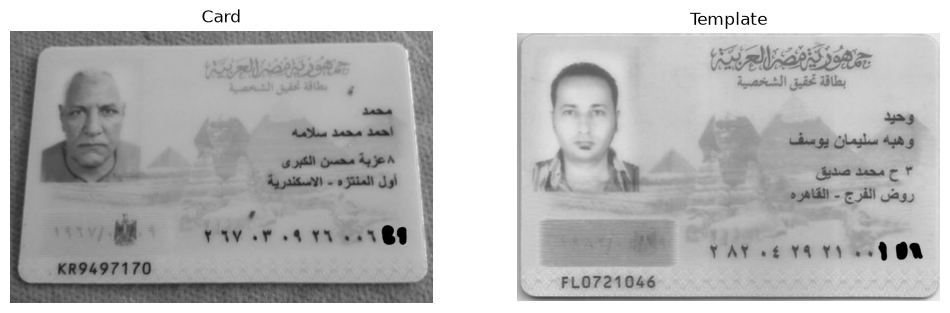

In [2]:
card = cv2.imread(
    r"c:\Users\HP\Desktop\ids2026\InkedScreenshot 2026-08-16 144900_LI.jpg"
)

template = cv2.imread(
    r"c:\Users\HP\Desktop\ids2026\InkedT - Copy_LI.jpg"
)
gray_card = cv2.cvtColor(
    card,
    cv2.COLOR_BGR2GRAY
)

gray_template = cv2.cvtColor(
    template,
    cv2.COLOR_BGR2GRAY
)

print("Card shape:", card.shape)
print("Template shape:", template.shape)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(gray_card, cv2.COLOR_BGR2RGB))
plt.title("Card")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(gray_template, cv2.COLOR_BGR2RGB))
plt.title("Template")
plt.axis("off")

plt.show()

In [3]:
sift = cv2.SIFT_create(
    nfeatures=5000,
    contrastThreshold=0.02,
    edgeThreshold=10,
    sigma=1.6
)
keypoints_card, descriptors_card = sift.detectAndCompute(
    gray_card,
    None
)

keypoints_template, descriptors_template = sift.detectAndCompute(
    gray_template,
    None
)

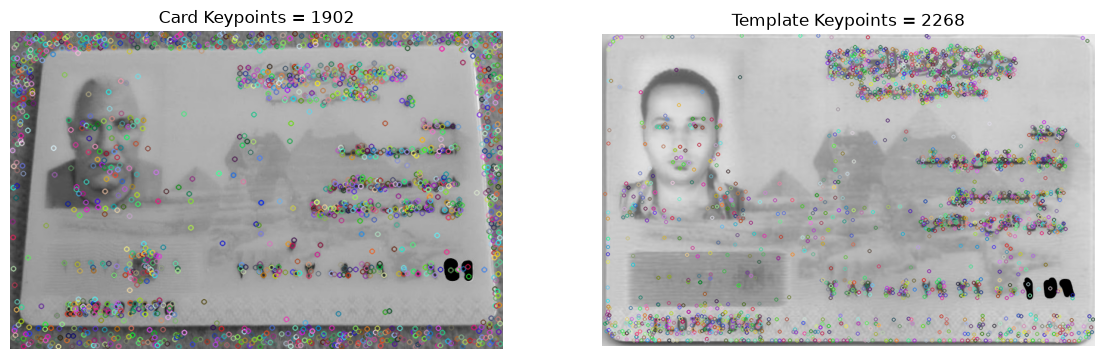

In [4]:
card_with_keypoints = cv2.drawKeypoints(
    gray_card,
    keypoints_card,
    None
)

template_with_keypoints = cv2.drawKeypoints(
    gray_template,
    keypoints_template,
    None
)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(card_with_keypoints, cmap="gray")
plt.title(f"Card Keypoints = {len(keypoints_card)}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(template_with_keypoints, cmap="gray")
plt.title(f"Template Keypoints = {len(keypoints_template)}")
plt.axis("off")

plt.show()

In [5]:
matcher = cv2.BFMatcher(
    cv2.NORM_L2,
    crossCheck=False
)
matches = matcher.knnMatch(
    descriptors_card,
    descriptors_template,
    k=2
)

In [6]:
print("Number of query descriptors:", len(matches))
print("Example:", matches[0])

Number of query descriptors: 1902
Example: (< cv2.DMatch 000001E13901BF10>, < cv2.DMatch 000001E15DC718F0>)


In [7]:
raw_matches = []

for pair in matches:
    if len(pair) >= 1:
        raw_matches.append(pair[0])

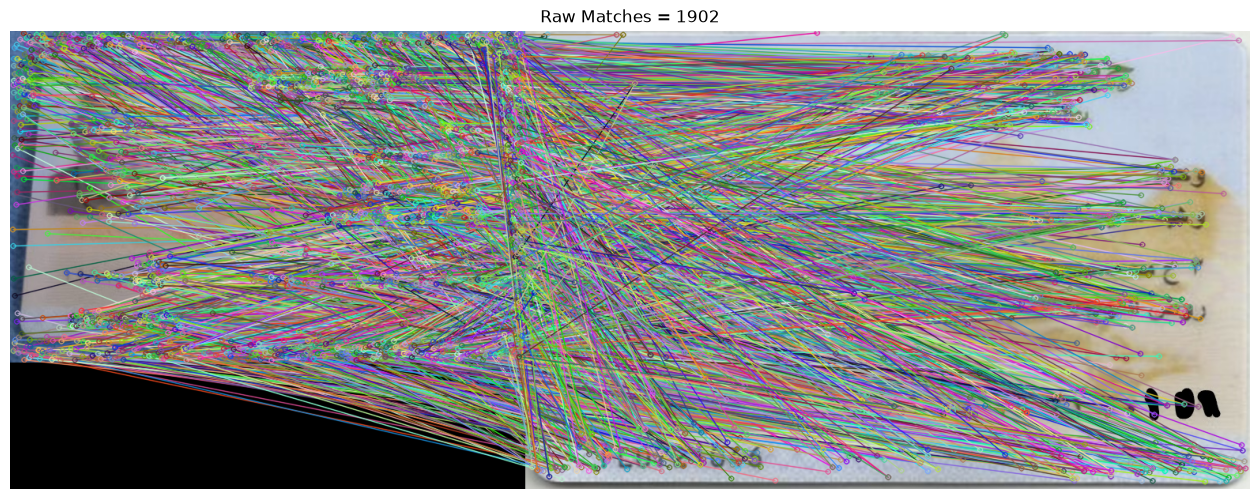

In [8]:
match_image = cv2.drawMatches(
    card,
    keypoints_card,
    template,
    keypoints_template,
    raw_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))

plt.imshow(
    cv2.cvtColor(
        match_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Raw Matches = {len(raw_matches)}"
)

plt.axis("off")
plt.show()

In [9]:
good_matches = []

for pair in matches:

    if len(pair) < 2:
        continue

    m, n = pair

    if m.distance < 0.70 * n.distance:
        good_matches.append(m)

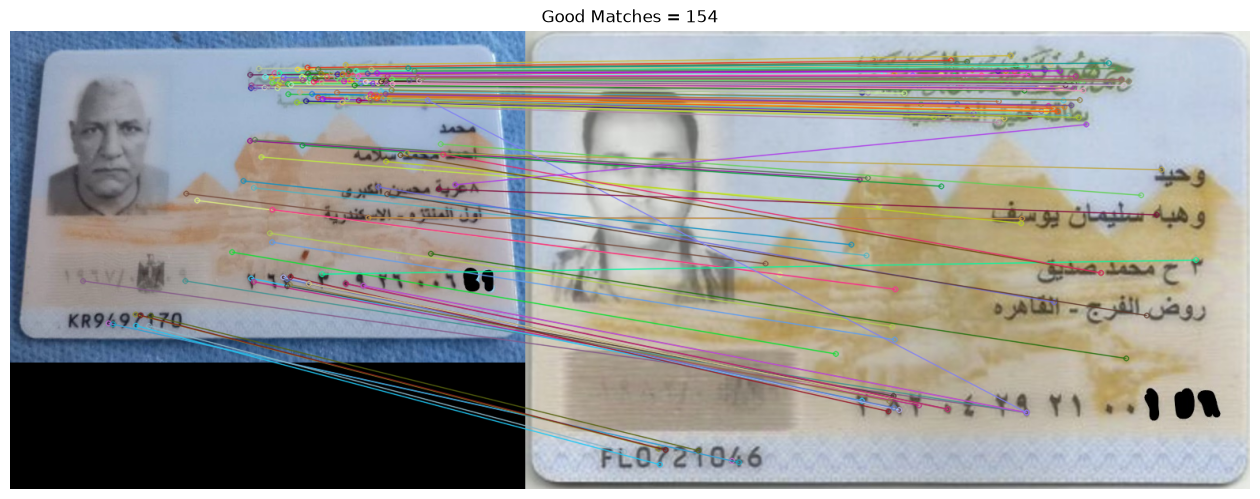

In [10]:
good_match_image = cv2.drawMatches(
    card,
    keypoints_card,
    template,
    keypoints_template,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))

plt.imshow(
    cv2.cvtColor(
        good_match_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Good Matches = {len(good_matches)}"
)

plt.axis("off")
plt.show()

In [11]:
src_points = np.float32([
    keypoints_card[m.queryIdx].pt
    for m in good_matches
]).reshape(-1, 1, 2)
dst_points = np.float32([
    keypoints_template[m.trainIdx].pt
    for m in good_matches
]).reshape(-1, 1, 2)


In [12]:
print("src_points shape:", src_points.shape)
print("dst_points shape:", dst_points.shape)

print("First 5 source points:")
print(src_points[:5])

print("First 5 destination points:")
print(dst_points[:5])

src_points shape: (154, 1, 2)
dst_points shape: (154, 1, 2)
First 5 source points:
[[[     92.012      316.33]]

 [[     124.24      369.88]]

 [[     129.97       371.1]]

 [[     158.59      358.64]]

 [[     158.94      372.82]]]
First 5 destination points:
[[[     633.87      482.82]]

 [[     261.11       543.8]]

 [[     269.85      545.79]]

 [[     168.15      528.64]]

 [[     169.85      548.65]]]


In [13]:
H, mask = cv2.findHomography(
    src_points,
    dst_points,
    cv2.RANSAC,
    5.0
)
print("Homography matrix:")
print(H)

Homography matrix:
[[     1.6738     0.14678     -76.874]
 [   0.036283      1.7952     -60.073]
 [ 6.6016e-05  0.00031458           1]]


In [14]:
print(mask.shape)
print(mask[:10])

(154, 1)
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]]


In [15]:
mask = mask.ravel()

inliers = int(mask.sum())

inlier_ratio = inliers / len(good_matches)

print("Good matches:", len(good_matches))
print("Inliers:", inliers)
print("Inlier ratio:", inlier_ratio)

Good matches: 154
Inliers: 116
Inlier ratio: 0.7532467532467533


In [16]:
inlier_matches = [
    m
    for i, m in enumerate(good_matches)
    if mask[i]
]

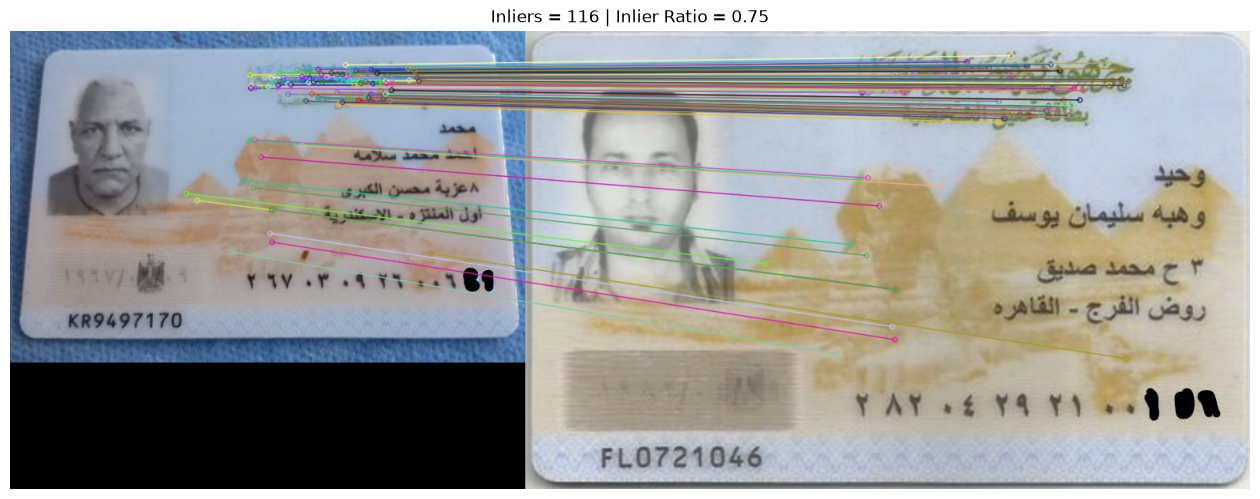

In [17]:
inlier_image = cv2.drawMatches(
    card,
    keypoints_card,
    template,
    keypoints_template,
    inlier_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))

plt.imshow(
    cv2.cvtColor(
        inlier_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Inliers = {inliers} | Inlier Ratio = {inlier_ratio:.2f}"
)

plt.axis("off")

plt.show()

In [18]:
if inlier_ratio < 0.30:
    print("BAD HOMOGRAPHY")
else:
    print("GOOD HOMOGRAPHY")

GOOD HOMOGRAPHY


In [19]:
template_h, template_w = template.shape[:2]

print("Template width:", template_w)

print("Template height:", template_h)

Template width: 917
Template height: 580


In [20]:
direct_aligned = cv2.warpPerspective(
    card,
    H,
    (template_w, template_h)
)

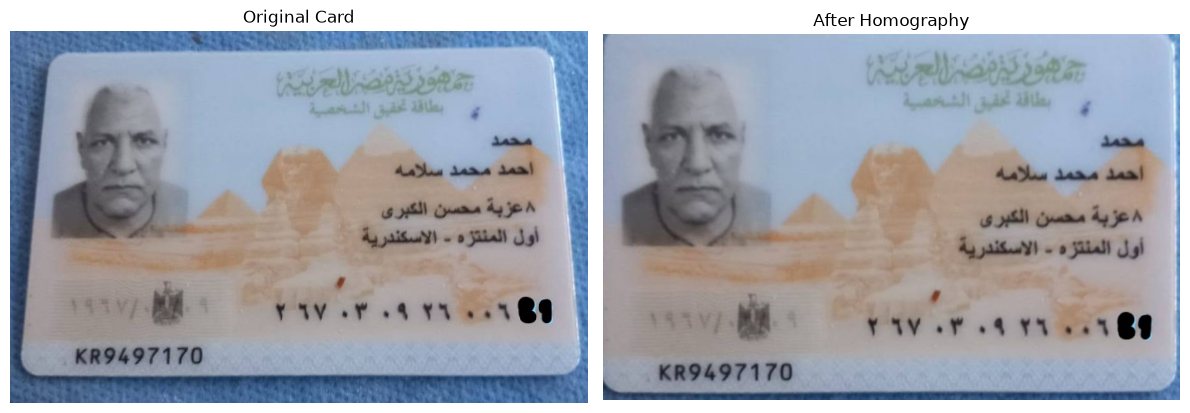

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    cv2.cvtColor(
        card,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Original Card")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    cv2.cvtColor(
        direct_aligned,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("After Homography")

plt.axis("off")

plt.tight_layout()

plt.show()